# Alanine-scanning distribution comparison

**Scope.** This notebook is the second of two pre-training, dataset-level exploratory
analyses named in Implementation Spec §5 (Metrics): a raw-dataset comparison, before any
model exists, of the ΔΔG distribution for **alanine-scanning** mutations (X → A,
`MutationRecord.is_alanine_scanning`) against all **other** single-point substitutions.

A **separate** post-training version of this same analysis is implemented under
`dl/metrics/` and operates on trained-model *predictions*. This notebook only looks at
ground-truth labels.

Alanine scanning is a common experimental technique (truncating a side chain down to a
methyl group) and is often reported to be more destabilizing on average than a random
substitution, since it removes side-chain contacts wholesale rather than swapping one
side chain for another of similar size/chemistry. **This notebook does not presume that
conclusion** — every number and plot below is computed from `df`, so it reports whatever
the loaded dataset (synthetic now, real SKEMPI records later) actually shows.

Every `MutationRecord` row already represents a single wt→mutant substitution at one
`residue_position`, so "other single-point substitutions" is simply every row with
`is_alanine_scanning == False` — no row-level filtering is needed. One caveat worth
knowing before reading the results: a real SKEMPI entry that mutated *several* residues
at once (a multi-point mutant) is stored as several rows sharing one `sample_id` and one
measured `ddg_kcal_mol` — each row is still a single substitution structurally, but its
ddG reflects the whole mutant complex, not that residue in isolation. The data-loading
section below reports how many rows this affects.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats


def resolve_repo_root() -> Path:
    return Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()


def add_repo_root_to_sys_path() -> Path:
    repo_root = resolve_repo_root()
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    return repo_root


REPO_ROOT = add_repo_root_to_sys_path()


In [2]:
sns.set_theme(style="whitegrid")

ALANINE_SCANNING_LABEL = "alanine-scanning (X\u2192A)"
OTHER_SUBSTITUTION_LABEL = "other substitution"
GROUP_ORDER = [ALANINE_SCANNING_LABEL, OTHER_SUBSTITUTION_LABEL]
GROUP_PALETTE = dict(zip(GROUP_ORDER, ["#2a78d6", "#eb6834"]))


The fixed two-color assignment above (`GROUP_PALETTE`) uses the same colorblind-safe,
validated categorical palette as notebook 01, in a fixed order (alanine-scanning first).

## Data loading

Same loader as notebook 01: `notebooks.processed_data.load_processed_dataframe` reads and combines the four split CSVs in `shared.constants.SPLIT_FILES` into a flat DataFrame, one row per point mutation.

In [3]:
from notebooks.processed_data import load_processed_dataframe


def label_scan_group(data: pd.DataFrame) -> pd.Series:
    return np.where(data["is_alanine_scanning"], ALANINE_SCANNING_LABEL, OTHER_SUBSTITUTION_LABEL)


df = load_processed_dataframe()
df["scan_group"] = label_scan_group(df)

print(f"Loaded {len(df)} point-mutation rows")
print(df["scan_group"].value_counts())

Loaded 2083 point-mutation rows
scan_group
other substitution        1480
alanine-scanning (X→A)     603
Name: count, dtype: int64


In [4]:
def rows_per_sample_id(data: pd.DataFrame) -> pd.Series:
    return data.groupby("sample_id").size()


def multi_point_mutation_row_count(data: pd.DataFrame) -> int:
    counts = rows_per_sample_id(data)
    multi_point_sample_ids = counts[counts > 1].index
    return int(data["sample_id"].isin(multi_point_sample_ids).sum())


print(f"Distinct measurements (unique sample_id): {df['sample_id'].nunique()}")
print(
    "Rows belonging to a multi-point-mutation measurement: "
    f"{multi_point_mutation_row_count(df)} / {len(df)}"
)


Distinct measurements (unique sample_id): 1057
Rows belonging to a multi-point-mutation measurement: 1374 / 2083


## Analysis 2 — ΔΔG: alanine-scanning vs. other substitutions

Restricted to records with a numeric `ddg_kcal_mol` (as in notebook 01, this includes
bounded entries plus any ineq entries carrying a best-effort numeric bound).

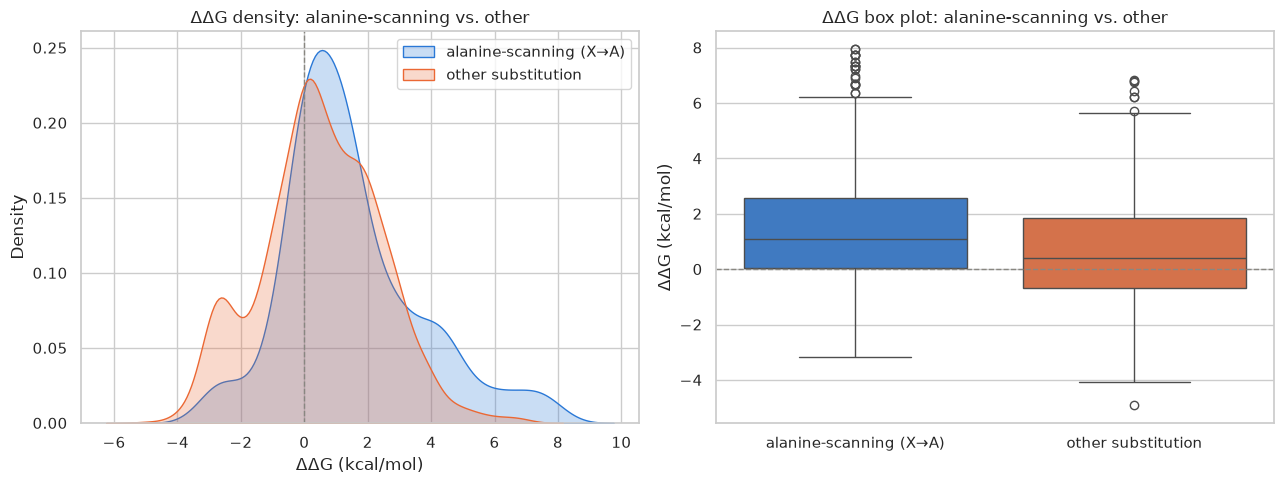

In [5]:
def rows_with_numeric_ddg(data: pd.DataFrame) -> pd.DataFrame:
    return data[data["ddg_kcal_mol"].notna()].copy()


def plot_ddg_kde_by_group(ax: plt.Axes, data: pd.DataFrame, order: list[str], palette: dict[str, str]) -> None:
    for group in order:
        subset = data.loc[data["scan_group"] == group, "ddg_kcal_mol"]
        sns.kdeplot(subset, label=group, color=palette[group], fill=True, alpha=0.25, ax=ax)
    ax.axvline(0, color="#898781", linewidth=1, linestyle="--")
    ax.set_title("ΔΔG density: alanine-scanning vs. other")
    ax.set_xlabel("ΔΔG (kcal/mol)")
    ax.legend()


def plot_ddg_box_by_group(ax: plt.Axes, data: pd.DataFrame, order: list[str], palette: dict[str, str]) -> None:
    sns.boxplot(
        data=data, x="scan_group", y="ddg_kcal_mol", order=order,
        hue="scan_group", palette=palette, legend=False, ax=ax,
    )
    ax.axhline(0, color="#898781", linewidth=1, linestyle="--")
    ax.set_title("ΔΔG box plot: alanine-scanning vs. other")
    ax.set_xlabel("")
    ax.set_ylabel("ΔΔG (kcal/mol)")


plot_df = rows_with_numeric_ddg(df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_ddg_kde_by_group(axes[0], plot_df, GROUP_ORDER, GROUP_PALETTE)
plot_ddg_box_by_group(axes[1], plot_df, GROUP_ORDER, GROUP_PALETTE)
fig.tight_layout()
plt.show()


In [6]:
def summarize_ddg_by_group(data: pd.DataFrame, order: list[str]) -> pd.DataFrame:
    return (
        data.groupby("scan_group")["ddg_kcal_mol"]
        .agg(n="count", mean="mean", median="median", std="std")
        .reindex(order)
    )


def ddg_values_for_group(data: pd.DataFrame, group: str) -> pd.Series:
    return data.loc[data["scan_group"] == group, "ddg_kcal_mol"]


def mann_whitney_two_sided(a: pd.Series, b: pd.Series) -> tuple[float, float]:
    """Distribution-free two-sample test -- makes no assumption that either group
    is Gaussian, unlike a t-test."""
    return stats.mannwhitneyu(a, b, alternative="two-sided")


def describe_group_difference(summary: pd.DataFrame, order: list[str], p_value: float) -> str:
    mean_diff = summary.loc[order[0], "mean"] - summary.loc[order[1], "mean"]
    direction = "more" if mean_diff > 0 else "less"
    return (
        f"In this dataset, alanine-scanning mutations average {abs(mean_diff):.2f} kcal/mol "
        f"{direction} destabilizing than other single-point substitutions "
        f"(mean {summary.loc[order[0], 'mean']:.2f} vs. {summary.loc[order[1], 'mean']:.2f} "
        f"kcal/mol; Mann-Whitney p={p_value:.2e})."
    )


scan_group_summary = summarize_ddg_by_group(plot_df, GROUP_ORDER)
print(scan_group_summary.round(3))

u_stat, u_p = mann_whitney_two_sided(
    ddg_values_for_group(plot_df, GROUP_ORDER[0]),
    ddg_values_for_group(plot_df, GROUP_ORDER[1]),
)
print(f"\nMann-Whitney U: U={u_stat:.1f}, p={u_p:.2e}")

print(f"\n{describe_group_difference(scan_group_summary, GROUP_ORDER, u_p)}")


                           n   mean  median    std
scan_group                                        
alanine-scanning (X→A)   555  1.450   1.078  2.141
other substitution      1300  0.514   0.410  1.872

Mann-Whitney U: U=439979.5, p=6.37e-14

In this dataset, alanine-scanning mutations average 0.94 kcal/mol more destabilizing than other single-point substitutions (mean 1.45 vs. 0.51 kcal/mol; Mann-Whitney p=6.37e-14).


**Reading this.** As in notebook 01, the printed summary, Mann-Whitney test, and the auto-generated sentence above are computed directly from real SKEMPI antibody-antigen records. Keep the multi-point-mutation caveat from the data-loading section in mind: a minority of rows carry a ddG shared with other substitutions from the same multi-point measurement, so the two groups compared here are not guaranteed to be fully independent observations.

## Summary

This notebook computes the ΔΔG distribution for alanine-scanning (X→A) mutations vs. all other single-point substitutions: an overlaid KDE, a box plot, per-group mean/median/std, and a Mann-Whitney U test for whether the two distributions differ. All of it is read directly off real SKEMPI antibody-antigen records via `notebooks.processed_data.load_processed_dataframe`.